#### Análisis y Procesamiento de Señales

# Trabajo Práctico N°0

#### Rey Tomás 

# Librerias

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Definiciones

In [11]:
fs=1000 #hz
N= 1000 #muestras

N es nuestro número de muestras y fs es la frecuencia con la que serán tomadas. El tiempo entre muestra y muestra es de 1/1000hz=1ms, por lo que el experimento total tardará 1000ms*1000muestras=1 segundo

In [12]:
def mi_funcion_sen (vmax,dc,ff,ph,nn,fs):
    tt=(np.arange(0,nn)/fs).reshape(-1,1)
    xx=vmax*np.sin(2*np.pi*ff*tt+ph)+dc
    return (tt,xx)

Defino una funcion que tome como parámetros la amplitud máxima de mi señal, el offset dc, fs es la frecuencia con la que se discretiza la señal en el tiempo mientras que ff es la frecuencia de la señal analógica. ph es el desfasaje de la función y nn es el número de muestras. Con todas estas variables, se genera un vector de tiempo, dividiendo cada muestra n por la frecuencia de sampling, y esa variable tt es luego usada para generar los valores de la señal

In [13]:
vmax=1.
dc=0
ff=3
ph=3

# *ff=3 hz*

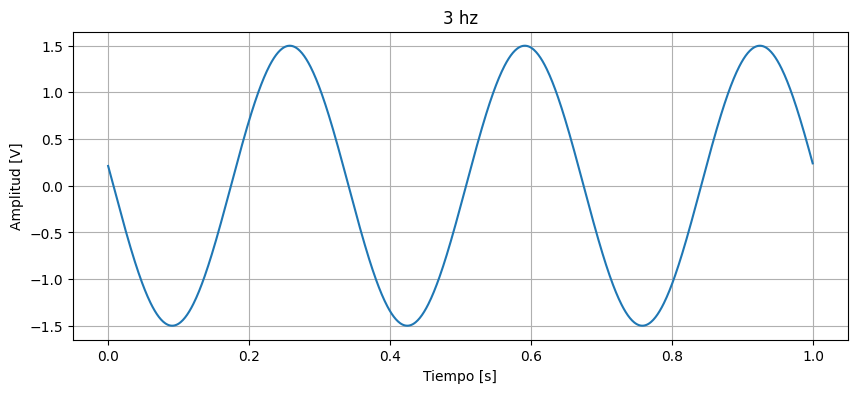

In [14]:
tt,xx=mi_funcion_sen(vmax,dc,ff,ph,N,fs)
plt.figure (figsize=(10,4))
plt.plot(tt,xx)
plt.ylabel('Amplitud [V]')
plt.xlabel('Tiempo [s]')
plt.title('3 hz')
plt.grid(True)
plt.show()

Muy por debajo de la frecuencia de Nyquist (3hz<<500hz), se toman aproximadamente 333 muestras por ciclo, por lo que la señal está sobremuestreada y la señal del seno está descrita a la perfección en el gráfico

# *ff=500 hz*

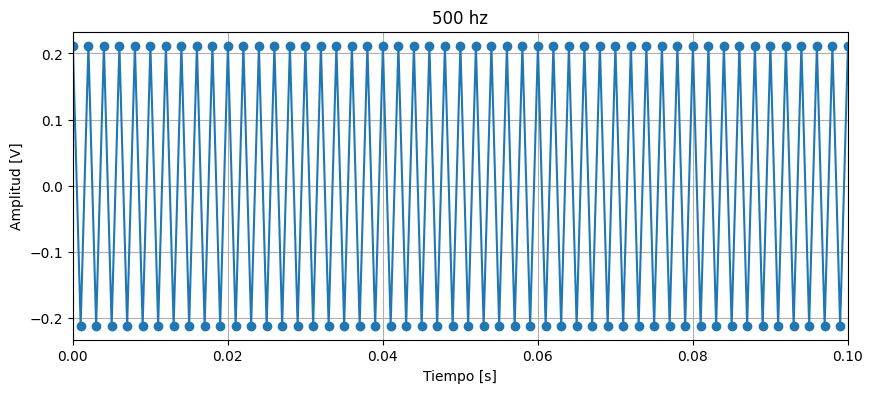

In [15]:
ff2=500
tt2,xx2=mi_funcion_sen(vmax,dc,ff2,ph,N,fs)
plt.figure (figsize=(10,4))
plt.xlim(0,0.1)
plt.plot(tt2,xx2,marker='o')
plt.ylabel('Amplitud [V]')
plt.xlabel('Tiempo [s]')
plt.title('500 hz')
plt.grid(True)
plt.show()

En este caso, la frecuencia de muestreo es exactamente el límite de Nyquist, permitiendo tan solo 2 muestras por ciclo, por lo que se pierde la fidelidad y se deja de apreciar la forma marcada de la señal sinusoidal. Se limito el eje x a 10 ms ya que debido a que mi fase es 3 que es muy cercano a pi, estoy sampleando siempre máximos y mínimos

# *ff=999 hz*

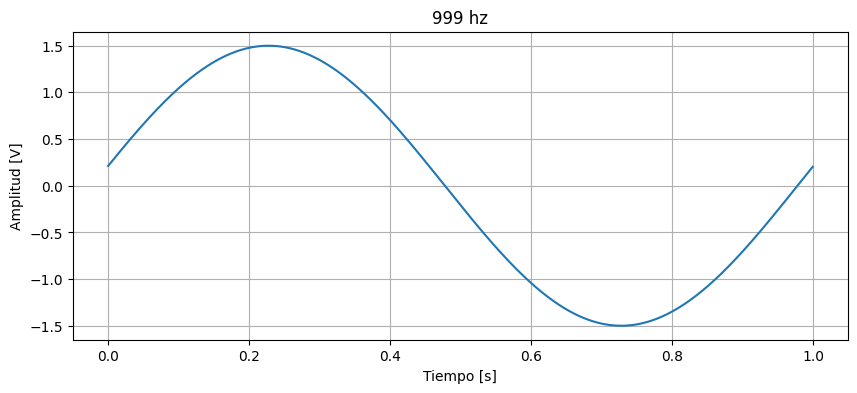

In [16]:
ff3=999
tt3,xx3=mi_funcion_sen(vmax,dc,ff3,ph,N,fs)
plt.figure (figsize=(10,4))
plt.plot(tt3,xx3)
plt.ylabel('Amplitud [V]')
plt.xlabel('Tiempo [s]')
plt.grid(True)
plt.title('999 hz')
plt.show()

Estamos por encima de la frecuencia de Nyquist y se produce un efecto de aliasing, donde |1000hz -999hz|=1hz, entonces este grafico es equivalente a uno de 1 hz

# *ff=2001 hz*

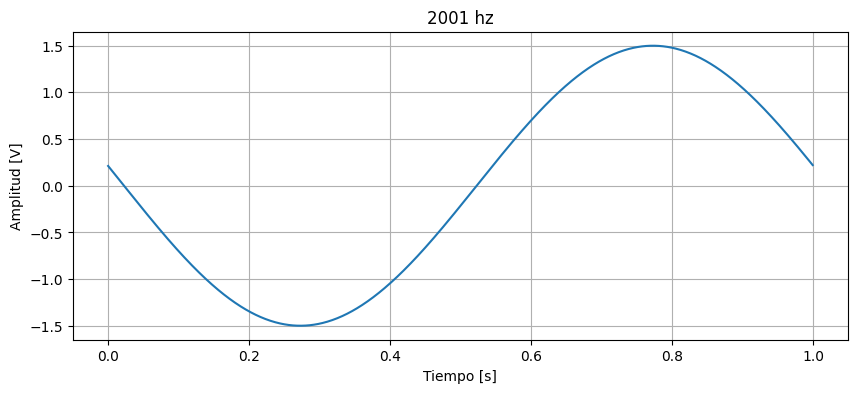

In [17]:
ff4=2001
tt4,xx4=mi_funcion_sen(vmax,dc,ff4,ph,N,fs)
plt.figure (figsize=(10,4))
plt.plot(tt4,xx4)
plt.ylabel('Amplitud [V]')
plt.xlabel('Tiempo [s]')
plt.grid(True)
plt.title('2001 hz')
plt.show()

En este caso, estamos más de 2 veces por encima de la frecuencia base, por lo que caemos en la segunda zona de repliegue espectral. El gráfico es igual al anterior pero desplazado en pi/2, por eso empieza en el mismo valor de amplitud pero empieza a decrecer. Esto se debe a que aquí el aliasing está por encima de 2 veces la frecuencia base, mientras que en el anterior estaba por debajo de una vez la frecuencia base, es decir, |2001hz-1000hz|=1hz

# *Señal cuadrada*

Text(0.5, 1.0, 'señal cuadrada')

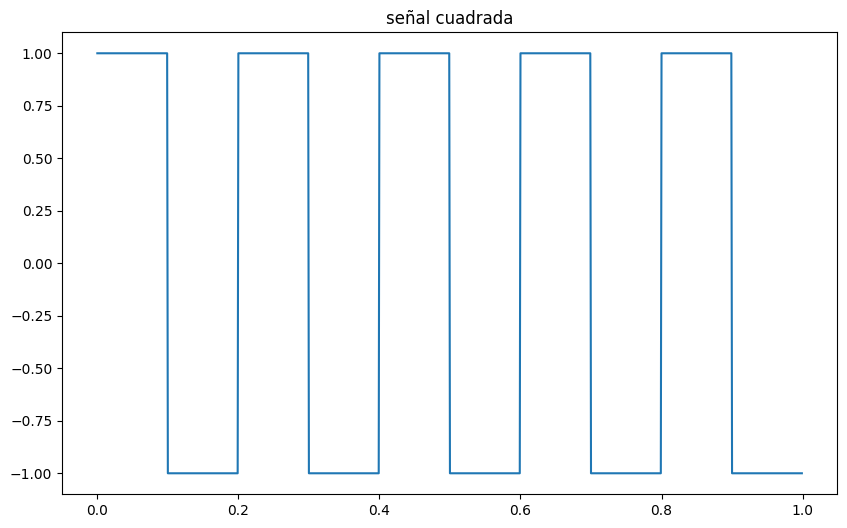

In [18]:
ffe=5
te=(np.arange(0,N)/fs).reshape(-1,1)
cuadrada=signal.square(2*np.pi*ffe*te)
plt.figure(figsize=(10, 6))
plt.plot(te, cuadrada)
plt.title("señal cuadrada")
